In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/spam_ham_dataset.csv")

# Display the first 5 rows
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [2]:
# Inspect the dataset structure

print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (5171, 4)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  5171 non-null   int64
 1   label       5171 non-null   str  
 2   text        5171 non-null   str  
 3   label_num   5171 non-null   int64
dtypes: int64(2), str(2)
memory usage: 161.7 KB


Check Spam/Ham Distribution and Missing Values

In [3]:
# Check missing values and class distribution

print("Missing Values:")
print(df.isnull().sum())

print("\nSpam/Ham Distribution:")
print(df["label"].value_counts())

Missing Values:
Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64

Spam/Ham Distribution:
label
ham     3672
spam    1499
Name: count, dtype: int64


In [4]:
# Remove the unnecessary index column

df = df.drop(columns=["Unnamed: 0"])

# Display the remaining columns
print("Remaining columns:")
print(df.columns.tolist())

df.head()

Remaining columns:
['label', 'text', 'label_num']


,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [6]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 178


In [7]:
# Remove duplicate rows

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())

Dataset shape after removing duplicates: (4993, 3)
Remaining duplicate rows: 0


Clean the Message Text

In [8]:
# Text preprocessing

import re

def clean_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", "", text)

    # Keep only letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply text cleaning
df["clean_text"] = df["text"].apply(clean_text)

# Display original and cleaned text
df[["text", "clean_text"]].head()

,text,clean_text
0,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter this is a follow ...
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom for january see attached file ...
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat ho ho ho we re around to ...
3,"Subject: photoshop , windows , office . cheap ...",subject photoshop windows office cheap main tr...
4,Subject: re : indian springs\r\nthis deal is t...,subject re indian springs this deal is to book...


In [9]:
# Check for empty cleaned messages

empty_messages = (df["clean_text"] == "").sum()

print("Empty cleaned messages:", empty_messages)
print("Total messages:", len(df))

Empty cleaned messages: 0
Total messages: 4993


Prepare Features and Target

For spam detection:

Input (X) → cleaned message text
Target (y) → label_num
0 = ham
1 = spam

We should have:
1. X containing the cleaned email messages.
2. y containing the numeric spam/ham labels.

In [10]:
# Prepare features and target

X = df["clean_text"]
y = df["label_num"]

print("Feature samples:")
print(X.head())

print("\nTarget distribution:")
print(y.value_counts())

Feature samples:
0    subject enron methanol meter this is a follow ...
1    subject hpl nom for january see attached file ...
2    subject neon retreat ho ho ho we re around to ...
3    subject photoshop windows office cheap main tr...
4    subject re indian springs this deal is to book...
Name: clean_text, dtype: str

Target distribution:
label_num
0    3531
1    1462
Name: count, dtype: int64


In [11]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 3994
Testing samples: 999

Training class distribution:
label_num
0    2825
1    1169
Name: count, dtype: int64

Testing class distribution:
label_num
0    706
1    293
Name: count, dtype: int64


Convert Text to TF-IDF Vectors

In [12]:
# Convert text into TF-IDF vectors

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

# Learn vocabulary from training data and transform it
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform test data using the same vocabulary
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (3994, 5000)
Testing TF-IDF shape: (999, 5000)


Train Naive Bayes Classifier

In [13]:
# Train Naive Bayes classifier

from sklearn.naive_bayes import MultinomialNB

naive_bayes_model = MultinomialNB()

naive_bayes_model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_nb = naive_bayes_model.predict(X_test_tfidf)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


Evaluate the Spam Detection Model

In [14]:
# Evaluate Naive Bayes classifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report
)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print("Naive Bayes Performance")
print("-----------------------")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1 Score :", round(nb_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=["Ham", "Spam"]
    )
)

Naive Bayes Performance
-----------------------
Accuracy : 0.953
Precision: 0.8892
Recall   : 0.959
F1 Score : 0.9228

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.95      0.97       706
        Spam       0.89      0.96      0.92       293

    accuracy                           0.95       999
   macro avg       0.94      0.95      0.94       999
weighted avg       0.96      0.95      0.95       999



Create the Confusion Matrix

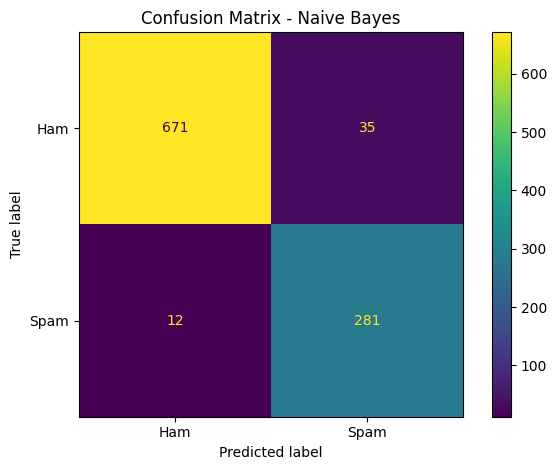

In [15]:
# Confusion Matrix - Naive Bayes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Confusion Matrix - Naive Bayes")
plt.tight_layout()

plt.savefig(
    "../outputs/confusion_matrix_naive_bayes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Build the Reusable TF-IDF + Naive Bayes Pipeline

In [16]:
# Create a reusable TF-IDF + Naive Bayes pipeline

from sklearn.pipeline import Pipeline

spam_detection_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=5000
    )),
    ("classifier", MultinomialNB())
])

# Train the complete pipeline using raw cleaned text
spam_detection_pipeline.fit(X_train, y_train)

print("Spam detection pipeline trained successfully.")

Spam detection pipeline trained successfully.


Evaluate the Complete Pipeline

Now we'll verify that the complete pipeline — TF-IDF + Naive Bayes — produces the same predictions as our earlier model.

In [17]:
# Evaluate the complete spam detection pipeline

y_pred_pipeline = spam_detection_pipeline.predict(X_test)

pipeline_accuracy = accuracy_score(y_test, y_pred_pipeline)
pipeline_precision = precision_score(y_test, y_pred_pipeline)
pipeline_recall = recall_score(y_test, y_pred_pipeline)
pipeline_f1 = f1_score(y_test, y_pred_pipeline)

print("Spam Detection Pipeline Performance")
print("-----------------------------------")
print("Accuracy :", round(pipeline_accuracy, 4))
print("Precision:", round(pipeline_precision, 4))
print("Recall   :", round(pipeline_recall, 4))
print("F1 Score :", round(pipeline_f1, 4))

Spam Detection Pipeline Performance
-----------------------------------
Accuracy : 0.953
Precision: 0.8892
Recall   : 0.959
F1 Score : 0.9228


Save the Complete Spam Detection Pipeline

In [18]:
# Save the complete spam detection pipeline

import joblib

pipeline_path = "../models/spam_detection_tfidf_naive_bayes_pipeline.pkl"

joblib.dump(
    spam_detection_pipeline,
    pipeline_path
)

print("Spam detection pipeline saved at:")
print(pipeline_path)

Spam detection pipeline saved at:
../models/spam_detection_tfidf_naive_bayes_pipeline.pkl


Test the Saved Pipeline with New Messages

In [19]:
# Load the saved spam detection pipeline

loaded_pipeline = joblib.load(
    "../models/spam_detection_tfidf_naive_bayes_pipeline.pkl"
)

# Test messages
test_messages = [
    "Congratulations! You have won a free prize. Click the link to claim your reward now.",
    "Hi, please send me the project report when you get time."
]

# Make predictions
predictions = loaded_pipeline.predict(test_messages)

# Display predictions
for message, prediction in zip(test_messages, predictions):
    label = "Spam" if prediction == 1 else "Ham"
    print("Message:", message)
    print("Prediction:", label)
    print("-" * 60)

Message: Congratulations! You have won a free prize. Click the link to claim your reward now.
Prediction: Spam
------------------------------------------------------------
Message: Hi, please send me the project report when you get time.
Prediction: Ham
------------------------------------------------------------


Create a Model Performance Visualization

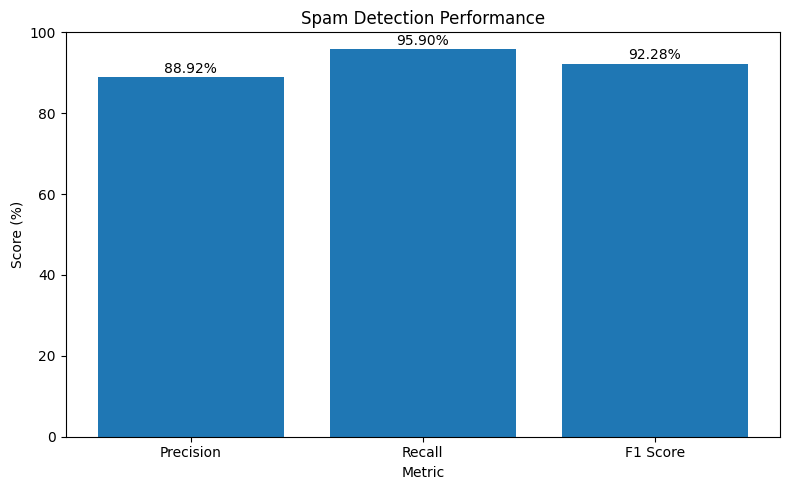

In [20]:
# Visualize Spam classification metrics

metrics = {
    "Precision": pipeline_precision,
    "Recall": pipeline_recall,
    "F1 Score": pipeline_f1
}

plt.figure(figsize=(8, 5))

plt.bar(
    metrics.keys(),
    [value * 100 for value in metrics.values()]
)

plt.xlabel("Metric")
plt.ylabel("Score (%)")
plt.title("Spam Detection Performance")
plt.ylim(0, 100)

# Display values above bars
for i, value in enumerate(metrics.values()):
    plt.text(
        i,
        value * 100 + 1,
        f"{value * 100:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/spam_detection_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()